In [1]:
from preprocessing import *
from preprocessing_bea import *
import numpy as np
import matplotlib.pyplot as plt
from helpers import *
from implementations import *

In [2]:
data_folder = 'C:/Users/ACER/OneDrive - epfl.ch/Desktop/ML/dataset/'


In [3]:
x_train,x_test, y_train,  feature_names = preprocess_data(data_folder, 0.3, True, 5, True, True, 0.95)

Dropped 180 features (56.1%)
Dropped feature names: ['CTELENUM', 'PVTRESD1', 'COLGHOUS', 'STATERES', 'CELLFON3', 'LADULT', 'NUMADULT', 'NUMMEN', 'NUMWOMEN', 'CTELNUM1', 'CELLFON2', 'CADULT', 'PVTRESD2', 'CCLGHOUS', 'CSTATE', 'LANDLINE', 'HHADULT', 'POORHLTH', 'BPMEDS', 'ASTHNOW', 'DIABAGE2', 'NUMHHOL2', 'NUMPHON2', 'CPDEMO1', 'PREGNANT', 'SMOKDAY2', 'STOPSMK2', 'LASTSMK2', 'AVEDRNK2', 'DRNK3GE5', 'MAXDRNKS', 'FRUITJU1', 'EXRACT11', 'EXEROFT1', 'EXERHMM1', 'EXRACT21', 'EXEROFT2', 'EXERHMM2', 'LMTJOIN3', 'ARTHDIS2', 'ARTHSOCL', 'JOINPAIN', 'FLSHTMY2', 'IMFVPLAC', 'HIVTSTD3', 'WHRTST10', 'PDIABTST', 'PREDIAB1', 'INSULIN', 'BLDSUGAR', 'FEETCHK2', 'DOCTDIAB', 'CHKHEMO3', 'FEETCHK', 'EYEEXAM', 'DIABEYE', 'DIABEDU', 'CAREGIV1', 'CRGVREL1', 'CRGVLNG1', 'CRGVHRS1', 'CRGVPRB1', 'CRGVPERS', 'CRGVHOUS', 'CRGVMST2', 'CRGVEXPT', 'VIDFCLT2', 'VIREDIF3', 'VIPRFVS2', 'VINOCRE2', 'VIEYEXM2', 'VIINSUR2', 'VICTRCT4', 'VIGLUMA2', 'VIMACDG2', 'CIMEMLOS', 'CDHOUSE', 'CDASSIST', 'CDHELP', 'CDSOCIAL', 'CDDISCU

In [4]:
y_train_bin = (y_train == 1).astype(int)


In [5]:
len(y_train_bin[y_train_bin == 0])

299160

In [6]:
x_train, y_train, x_val, y_val = split_train_val(x_train, y_train_bin, val_size=0.1)

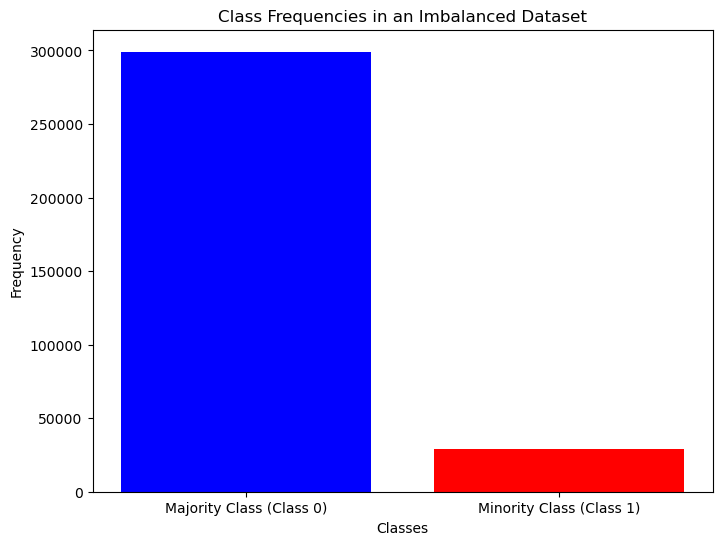

In [7]:

# Count the frequencies of each class
class_counts = [len(y_train_bin[y_train_bin == 0]), len(y_train_bin[y_train_bin == 1])]

# Plot the class frequencies using a bar chart
plt.figure(figsize=(8, 6))
plt.bar(['Majority Class (Class 0)', 'Minority Class (Class 1)'], class_counts, color=['blue', 'red'])
plt.xlabel('Classes')
plt.ylabel('Frequency')
plt.title('Class Frequencies in an Imbalanced Dataset')
plt.show()

In [25]:
def logistic_regression(y, tx, initial_w, max_iters, gamma):
    """Logistic regression using gradient descent (y ∈ {0,1}).

    Args:
        y (np.array): shape=(N,) target values
        tx (np.array): shape=(N,D) feature matrix
        initial_w (np.array): shape=(D,) initial weights
        max_iters (int): maximum number of gradient descent iterations
        gamma (float): learning rate

    Returns:
        w (np.array): shape=(D,) final weights
        loss (float): final loss value
    """
    # Minimize the negative log likelihood
    w = initial_w
    for _ in range(max_iters):
        # gradient descent step
        pred = sigmoid_stable(tx @ w)  # sigmoid function
        gradient = tx.T @ (pred - y) / len(y)  # gradient of the loss
        w -= gamma * gradient

    return w, logistic_negative_log_likelihood(y, tx, w)

def reg_logistic_regression(y, tx, lambda_, initial_w, max_iters, gamma):
    """Regularized logistic regression using gradient descent
        (y ∈ {0,1}, with regularization term λ∥w∥2)

    Args:
        y (np.array): shape=(N,) target values
        tx (np.array): shape=(N,D) feature matrix
        lambda_ (float): regularization parameter
        initial_w (np.array): shape=(D,) initial weights
        max_iters (int): maximum number of gradient descent iterations
        gamma (float): learning rate

    Returns:
        w (np.array): shape=(D,) final weights
        loss (float): final loss value
    """
    # Minimize the regularized negative log likelihood
    w = initial_w
    for _ in range(max_iters):
        # gradient descent step
        pred = sigmoid_stable(tx @ w)  # sigmoid function
        gradient = tx.T @ (pred - y) / len(y) + 2 * lambda_ * w  # gradient of the regularized loss
        w -= gamma * gradient

    return w, logistic_negative_log_likelihood(y, tx, w)


#Logistic regression model training and evaluation
def predict_labels(tx, w, threshold=0.5):
    pred = sigmoid_stable(tx @ w)
    return (pred >= threshold).astype(int)

def logistic_negative_log_likelihood(y, tx, w):
    """Compute the negative log likelihood for logistic regression.

    Args:
        y (np.array): shape=(N,) target values
        tx (np.array): shape=(N,D) feature matrix
        w (np.array): shape=(D,) weights
    Returns:
        float: negative log likelihood loss value
    """
    # - mean(y log(pred) + (1-y) log(1-pred))
    # with pred = sigmoid(tx @ w)
    # More efficient implementation after a few algebraic manipulations
    return np.mean(- y * (tx @ w) + np.log(1 + np.exp(tx @ w)))

In [26]:
w, loss = logistic_regression(y_train, x_train, np.zeros(x_train.shape[1]), 1000, 0.01)

In [29]:
y_pred = predict_labels(x_val, w, 0.01)

In [30]:
len(y_pred[y_pred == 1])

0

In [24]:
def sigmoid_stable(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def train_logreg_weighted(x, y, lr=0.01, epochs=1000, lambda_=0.0):
    N, D = x.shape
    w = np.zeros(D)
    b = 0.0

    n_pos = np.sum(y==1)
    n_neg = np.sum(y==0)
    w_pos = N / (2 * max(n_pos,1))
    w_neg = N / (2 * max(n_neg,1))
    sample_weights = np.where(y==1, w_pos, w_neg)  # shape (N,)

    for _ in range(epochs):
        z = x @ w + b
        p = sigmoid_stable(z)
        err = (p - y) * sample_weights  # shape (N,)
        dw = (x.T @ err) / N + lambda_ * w
        db = np.sum(err) / N
        w -= lr * dw
        b -= lr * db

    return w, b

def f1_score(y_true, y_pred):
    tp = np.sum((y_true==1) & (y_pred==1))
    fp = np.sum((y_true==0) & (y_pred==1))
    fn = np.sum((y_true==1) & (y_pred==0))
    if tp+fp+fn == 0:
        return 0.0
    p = tp / (tp + fp + 1e-12)
    r = tp / (tp + fn + 1e-12)
    return 2*p*r / (p+r+1e-12)

def best_threshold_by_f1(y_val, probs, thresholds=np.linspace(0,1,101)):
    best_t, best_f1 = 0.5, -1
    for t in thresholds:
        preds = (probs >= t).astype(int)
        f1 = f1_score(y_val, preds)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


In [9]:
w_w, b_w = train_logreg_weighted(x_train,y_train, lr=0.001, epochs=2000, lambda_=0.0)

KeyboardInterrupt: 

In [ ]:
w, b = logistic_regression_train(x_train,y_train, lr=0.001, epochs=2000, lambda_=0.1)


In [ ]:
for threshold in np.arange(0.0 ,1.0 ,0.01):
    y_pred, _ = logistic_regression_predict(x_val, w_w, b_w, threshold)

    acc, f1 = evaluate_classification(y_val, y_pred)
    print(f"Threshold: {threshold:.2f}")
    print(f"Accuracy: {acc:.3f}")
    print(f"F1 Score: {f1:.3f}")

Threshold: 0.00
Accuracy: 0.088
F1 Score: 0.162
Threshold: 0.01
Accuracy: 0.900
F1 Score: 0.028
Threshold: 0.02
Accuracy: 0.901
F1 Score: 0.027
Threshold: 0.03
Accuracy: 0.902
F1 Score: 0.026
Threshold: 0.04
Accuracy: 0.902
F1 Score: 0.025
Threshold: 0.05
Accuracy: 0.902
F1 Score: 0.025
Threshold: 0.06
Accuracy: 0.903
F1 Score: 0.025
Threshold: 0.07
Accuracy: 0.903
F1 Score: 0.024
Threshold: 0.08
Accuracy: 0.903
F1 Score: 0.023
Threshold: 0.09
Accuracy: 0.903
F1 Score: 0.023
Threshold: 0.10
Accuracy: 0.903
F1 Score: 0.022
Threshold: 0.11
Accuracy: 0.903
F1 Score: 0.022
Threshold: 0.12
Accuracy: 0.903
F1 Score: 0.022
Threshold: 0.13
Accuracy: 0.903
F1 Score: 0.022
Threshold: 0.14
Accuracy: 0.904
F1 Score: 0.022
Threshold: 0.15
Accuracy: 0.904
F1 Score: 0.021
Threshold: 0.16
Accuracy: 0.904
F1 Score: 0.020
Threshold: 0.17
Accuracy: 0.904
F1 Score: 0.021
Threshold: 0.18
Accuracy: 0.904
F1 Score: 0.021
Threshold: 0.19
Accuracy: 0.904
F1 Score: 0.021
Threshold: 0.20
Accuracy: 0.904
F1 Score

In [ ]:
def oversample_minority(x_train, y_train, target_ratio=0.5, random_seed=0):
    """
    Duplicate minority class until minority fraction ≈ target_ratio (0<target_ratio<1).
    Returns x_res, y_res (shuffled).
    """
    rng = np.random.default_rng(random_seed)
    pos_idx = np.where(y_train==1)[0]
    neg_idx = np.where(y_train==0)[0]
    n_pos = len(pos_idx)
    n_neg = len(neg_idx)

    if n_pos == 0:
        return x_train.copy(), y_train.copy()

    # desired minority count
    desired_pos = int(target_ratio * (n_pos + n_neg) / (1 - target_ratio))
    if desired_pos <= n_pos:
        # already enough or target small -> no change
        return x_train.copy(), y_train.copy()

    # sample with replacement from minority
    sample_idx = rng.choice(pos_idx, size=(desired_pos - n_pos), replace=True)
    x_extra = x_train[sample_idx]
    y_extra = y_train[sample_idx]

    x_res = np.vstack([x_train, x_extra])
    y_res = np.concatenate([y_train, y_extra])

    # shuffle
    perm = rng.permutation(len(y_res))
    return x_res[perm], y_res[perm]


In [ ]:
# assume: x_train_full, y_train_full are your preprocessed training arrays
# split into train/val
x_tr, y_tr, x_val, y_val = split_train_val(x_train, y_train, val_size=0.1)

# 1) baseline: weighted logistic regression
w, b = train_logreg_weighted(x_tr, y_tr, lr=0.05, epochs=2000, lambda_=0.0)
probs_val = sigmoid_stable(x_val @ w + b)
best_t, best_f1 = best_threshold_by_f1(y_val, probs_val)
print("Weighted LR: best threshold", best_t, "val F1", best_f1)

# 2) oversample minority on training, then train (no class weight or can combine)
x_tr_os, y_tr_os = oversample_minority(x_tr, y_tr, target_ratio=0.5)
w2, b2 = train_logreg_weighted(x_tr_os, y_tr_os, lr=0.05, epochs=2000, lambda_=0.0)
probs_val2 = sigmoid_stable(x_val @ w2 + b2)
best_t2, best_f12 = best_threshold_by_f1(y_val, probs_val2)
print("Oversampled LR: best threshold", best_t2, "val F1", best_f12)

# pick the approach with better val F1


Weighted LR: best threshold 0.0 val F1 0.15965601046909966
Oversampled LR: best threshold 0.0 val F1 0.15965601046909966
